:::{admonition} Run this notebook yourself!
:class: important

Download the executed notebook: **{nb-download}`how_to_penalty.ipynb`**!

Run it in your browser: **{binder}`how_to_penalty.ipynb`**!

:::

(how-to-penalty)=
# How to use custom penalty functions

Plenoptic's {class}`~plenoptic.Metamer` and {class}`~plenoptic.MADCompetition` objects allow users to specify a {attr}`~plenoptic.Metamer.penalty_function` at initialization. In this notebook, we'll walk through the process of creating a custom penalty function and explain best practices. We will do so for {class}`~plenoptic.Metamer`, but a similar procedure can be applied to {class}`~plenoptic.MADCompetition`. We will refer to the stimuli as "images", but the same procedure will work with other stimulus types as well.

When synthesizing a metamer, we are searching for a new image whose model representation matches that of a target image. Plenoptic performs this procedure as an iterative optimization function, minimizing the objective function:

$$ L(M(x), M(\hat{x})) + \lambda P(\hat{x}) $$

where:

- $M$ is {attr}`~plenoptic.Metamer.model`, the model whose representation we are trying to match.
- $x$ is {attr}`~plenoptic.Metamer.image`, the image whose model representation we are trying to match.
- $\hat{x}$ is {attr}`~plenoptic.Metamer.metamer`, the image we are synthesizing.
- $L$ is {attr}`~plenoptic.Metamer.loss_function`, a function which accepts two tensors and returns a scalar, which defines how different two representation tensors are (by default, {func}`plenoptic.loss.mse`).
- $P$ is {attr}`~plenoptic.Metamer.penalty_function`, a function which accepts a single tensor and returns a scalar, and the focus of this notebook (by default, {func}`plenoptic.regularize.penalize_range`).
- $\lambda$ is {attr}`~plenoptic.Metamer.penalty_lambda`, a scalar that controls the balance between {attr}`~plenoptic.Metamer.loss_function` and {attr}`~plenoptic.Metamer.penalty_function` (by default, `0.1`).

All of the above are arguments passed at initialization of the {class}`~plenoptic.Metamer` object except $\hat{x}$ / {attr}`~plenoptic.Metamer.metamer`.

Thus, the metamer synthesis procedure balances the importance of two components, the metamer loss and the penalty. If you are familiar with optimization, you probably recognize that the penalty term is biasing the metamer optimization procedure: there is no guarantee that we can find an image that satisfies both criteria. That is, we may not be able to find a metamer such that the metamer loss and the penalty are both zero.

The default penalty function, {func}`~plenoptic.regularize.penalize_range`, places a quadratic penalty on any pixel values outside of the range $[0, 1]$. This is the default because all synthesized images need to be displayed, and a range of $[0, 1]$ (when dealing with floats) or $[0, 255]$ (when dealing with 8-bit integers) are typically used to represent the displayable range of values.

It is likely that we can find images that have minimal values for both the metamer loss and this default penalty. However, we cannot assume that is the case for more complicated penalty functions. This notebook will show some strategies to find good solutions, but you may find yourself in a situation where you have to choose which term to prioritize. If so, it is important to remember: for an image to be a model metamer, its metamer loss **must** be zero (see [](good-enough) and [](feather-synthesis-success) for discussion on what "zero" means in practice). If your scientific reasoning depends on your images being model metamers, this is non-negotiable. However, depending on your scientific question, it is likely that your penalty doesn't need to be met exactly, and you are thus encouraged to prioritize metamer loss.

In this notebook, we'll show how to change this penalty to restrict the metamer's pixel values to different ranges. We will cover three distinct points in this notebook, all of which are important to understand when using custom penalty functions:
- [Basic requirements and usage](penalty-basics): a penalty function must be a differentiable callable that accepts a single tensor and returns a single scalar, and is specified using the {attr}`~plenoptic.Metamer.penalty_function` argument at initialization.
- [Designing a well-behaved penalty function](penalty-well-behaved): a penalty function should have a finite minimum value which corresponds to the behavior you wish to encourage. This section additionally demonstrates how to combine multiple penalty functions with addition.
- [Selecting the proper {attr}`~plenoptic.Metamer.penalty_lambda` value](penalty-lambda): if the value is too small, the penalty will have no effect on metamer synthesis, whereas if it is too large, the penalty will dominate the objective function and the resulting image will not be a model metamer.

:::{admonition} What other penalties can I use?

This notebook demonstrates the technical requirements for {attr}`~plenoptic.Metamer.penalty_function`: it must be a differentiable function that accept a single tensor (the metamer-in-progress) and return a single scalar. **Which** function to use depends on your scientific question and what you're interested in. The other notebooks in this section demonstrate some additional uses of penalty functions beyond controlling the range of allowed pixel values. Additionally, see [](adversarial-examples-metamer) for an example using {class}`~plenoptic.Metamer` with {attr}`~plenoptic.Metamer.penalty_function` to generate deep net adversarial examples.

As far as the developers of plenoptic are aware, this use of penalties to bias metamer synthesis is novel, so we do not know of any existing examples in the literature. We presented a poster about it at the [Cognitive Computational Neuroscience 2026](https://2026.ccneuro.org/) conference, {cite:alp}`Broderick2026-biasing-optim` (poster available [here](https://dx.doi.org/10.17605/OSF.IO/R7JPS)), which shows three distinct uses of penalty functions in metamer synthesis.

If you are aware of examples of a similar use of penalties in the literature, please [tell us](https://github.com/plenoptic-org/plenoptic/discussions/new?category=general). We would also be very interested in [hearing from users](https://github.com/plenoptic-org/plenoptic/discussions/new?category=show-and-tell) who have used this procedure themselves!

:::

In [1]:
import os

import matplotlib.pyplot as plt
import torch

import plenoptic as po

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72

# The default value of 4000 for MAX_ITER here will lead to reasonable results, but will
# take too long if you don't have a GPU. If synthesis is taking a long time on your
# machine, set this to a lower value, but know that synthesis has ended early. View the
# website online to see what completed synthesis looks like.
MAX_ITER = int(os.environ.get("MAX_ITER", 4000))

The following hidden cell creates some plotting functions that we'll reuse throughout this notebook, expand it if you're interested in the details.

In [2]:
def create_metamer_figure(met, suptitle):
    """Create figure to summarize metamer synthesis and pixel values."""
    fig, axes = plt.subplots(2, 3, figsize=(16, 11))
    axes = axes.flatten()
    included_plots = ["synthesis_imshow", "synthesis_histogram"]
    axes_idx = {k: i + 1 for i, k in enumerate(included_plots)}
    po.plot.synthesis_status(
        met,
        fig=fig,
        included_plots=included_plots,
        axes_idx=axes_idx,
        synthesis_imshow_kwargs={"vrange": (0, 1)},
    )
    image_axes = [axes[0], axes[3], axes[4]]
    imgs = [met.image, met.model(met.image), met.model(met.metamer)]
    titles = ["Target image", "Representation of target", "Representation of metamer"]
    for ax, im, t in zip(image_axes, imgs, titles):
        po.plot.imshow(im, ax=ax, title=t, zoom=1, vrange=(0, 1))
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)
    axes[-1].set_visible(False)
    fig.suptitle(suptitle, fontsize="xx-large", fontweight="bold")
    return fig


def plot_penalty(img, custom_penalty, x_vlines, x_range):
    """Plot penalty over range of values."""
    # Create a 1d tensor of values with specified range
    vals = torch.linspace(*x_range, 100).to(img.dtype).to(img.device)
    # Take advantage of broadcasting to create a single tensor of shape (100, 1, 256,
    # 256) whose elements along the batch dimension are images with uniform pixel values
    imgs = vals.reshape(len(vals), 1, 1, 1) * torch.ones_like(img)
    # torch vmap allows us to apply custom_penalty independently across the 0th
    # dimension, so that we're applying it separately to each of our synthetic images.
    penalties = torch.func.vmap(custom_penalty)(imgs)
    fig, ax = plt.subplots(1, 1)
    ax.plot(po.to_numpy(vals), po.to_numpy(penalties))
    # Let's add some vertical lines showing where our min and max allowed values are.
    if not (penalties < 0).any():
        ylim = (-ax.get_ylim()[1] / 1000, ax.get_ylim()[1])
    elif not (penalties > 0).any():
        ylim = (ax.get_ylim()[0], -ax.get_ylim()[0] / 1000)
    else:
        ylim = ax.get_ylim()
    ax.vlines(x_vlines, *ylim, "k", "dashed")
    ax.set(ylim=ylim, xlabel="Pixel value", ylabel="Penalty value")
    return fig

## Default {class}`~plenoptic.Metamer` behavior

In this notebook, we'll use a simple {class}`~plenoptic.models.Gaussian` model. This model just convolves a Gaussian kernel across the entire image. It is thus a low-pass model, only caring about low frequencies and disregarding high frequencies.

First, let's see what metamer synthesis with the default penalty function looks like:

(default-penalty-figure)=

  0%|          | 0/4000 [00:00<?, ?it/s]

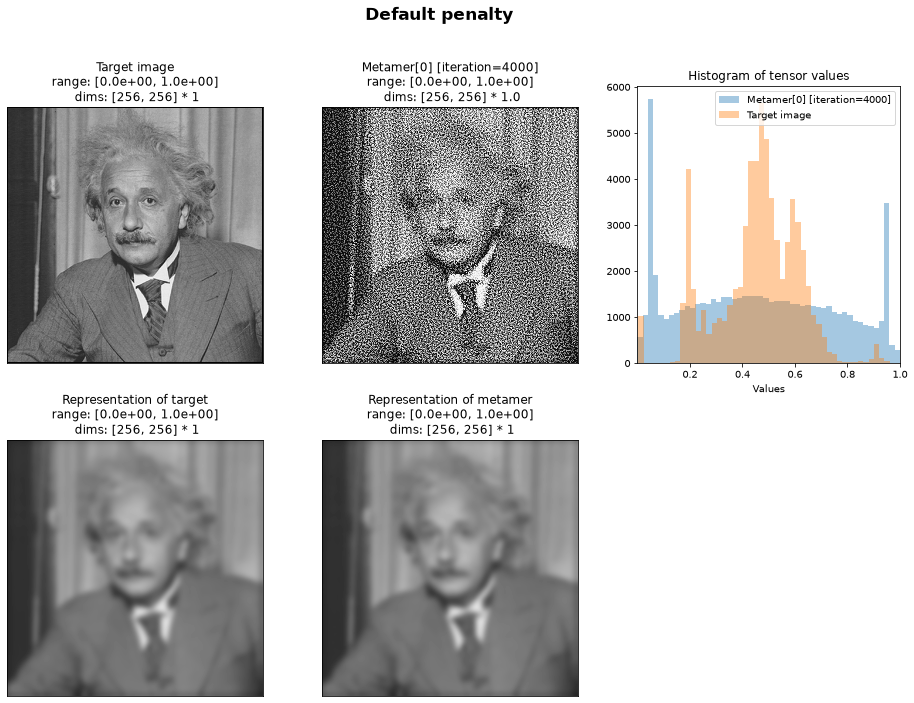

In [3]:
model = po.models.Gaussian(30, cache_filt=True).eval()
po.remove_grad(model)
model.to(DEVICE).to(torch.float64)
img = po.data.einstein().to(DEVICE).to(torch.float64)
met = po.Metamer(img, model)
met.synthesize(MAX_ITER, stop_criterion=1e-16)

# This plotting function was created in a hidden cell at the top of the notebook, expand
# it if you're interested in the details.
create_metamer_figure(met, "Default penalty");

In the above figure, the top row shows: the target image, the metamer, and a histogram of pixel values in those two images. The bottom row shows the model representation of the top two images. We can see that the two representations on the bottom match and thus the two images on the top are metamers.

By looking at the histogram (and the "range" section in the title of the images on the top row), we can see that the pixel values in our metamer vary between 0 and 1 and, since it was initialized with a patch of uniformly-distributed noise, those pixels are widely distributed between those values.

## Basic penalty function requirements and usage
(penalty-basics)=

All penalty functions in plenoptic must be callables that take the synthesized image as input and return some scalar penalty. We can write a custom penalty that makes use of the {func}`~plenoptic.regularize.penalize_range` function to penalize pixel values that fall outside some narrower range instead:

In [4]:
# Create custom_penalty function, that penalizes pixels outside of [0.1, 0.9] range
def custom_penalty(image):
    return po.regularize.penalize_range(image, allowed_range=(0.1, 0.9))

Our `custom_penalty` accepts a single tensor and returns a scalar, quadratic penalty on any values it contains outside of 0.1 to 0.9:

In [5]:
custom_penalty(img)

tensor(9.6853, device='cuda:0', dtype=torch.float64)

To understand the penalty's behavior, let's plot its output on some synthetic images. The following helper function constructs images the same shape as `img` but whose pixel values all have the same value, and we'll have these values range from $-0.2$ to $1.2$:

(well-behaved-range-penalty)=

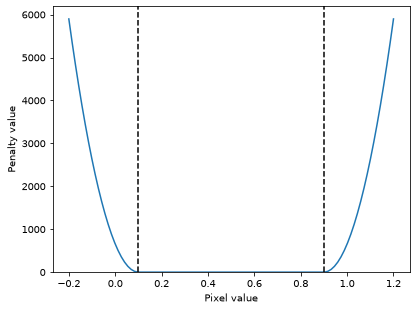

In [6]:
# This plotting function was created in a hidden cell at the top of the notebook, expand
# it if you're interested in the details.
plot_penalty(img, custom_penalty, x_vlines=[0.1, 0.9], x_range=(-0.2, 1.2));

In the above plot, the penalty value is on the y-axis and the pixel value of the penalized image is on the x-axis. The goal of this penalty is to encourage the pixel values to lie within the range $[0.1, 0.9]$. We can see that the penalty value is 0 within the allowed range, whose boundaries are marked by the vertical dashed lines. Outside that range, we see the penalty rise sharply.

The slope / derivative of the penalty function tells us where its gradient will move the pixel values during the synthesis procedure: the slope is positive above $0.9$, zero within the allowed range, and negative below $0.1$. Therefore, the penalty will not affect any pixel values that fall between $0.1$ and $0.9$, while increasing those below that range and decreasing those above it (because we are minimizing the penalty, the effect on the pixels has the opposite sign of the gradient). Furthermore, the slope increases in magnitude the further away you get from the allowed range, so this penalty will have a strong effect on those values, while smoothly decreasing in strength as the pixels get closer to the boundaries.

Now that we understand its behavior, we can pass this `custom_penalty` to the {class}`~plenoptic.Metamer` class at initialization and call the {meth}`~plenoptic.Metamer.synthesize` method in the same manner as before:

:::{admonition} Multi-stage synthesis
:class: dropdown note

In the examples in this notebook, we will always call {func}`~plenoptic.Metamer.synthesize` once, simultaneously optimizing for the metamer loss and our custom penalty. For more complex penalty functions, however, we have often found better performance by breaking up the synthesis into multiple stages. That is, first call {func}`~plenoptic.Metamer.synthesize` without the custom penalty and then using the resulting un-penalized metamer to initialize a second synthesis procedure, like so:

```python
met = po.Metamer(img, model)
met.synthesize(1000, stop_criterion=1e-16)
met_penalty = po.Metamer(img, model, penalty_function=custom_penalty)
met.setup(initial_image=met.metamer)
met.synthesize(1000, stop_criterion=1e-16)
```

You are encouraged to try both methods and see which performs best for your use case.

:::

  0%|          | 0/4000 [00:00<?, ?it/s]

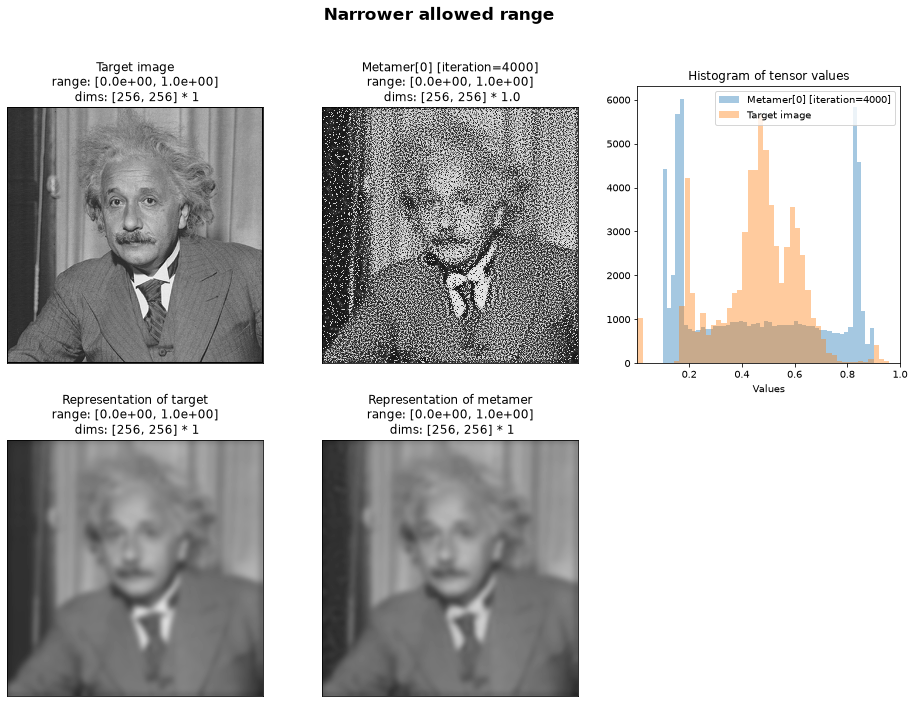

In [7]:
met = po.Metamer(img, model, penalty_function=custom_penalty)
met.synthesize(MAX_ITER, stop_criterion=1e-16)

create_metamer_figure(met, "Narrower allowed range");

The figure above has the same structure as earlier, and we can see that the new metamer's pixel values all fall within this narrower range of $[0.1, 0.9]$. By looking at the second row, we can see that this image is still a metamer: the representation still looks identical to that of the target image.

:::{admonition} Why not clamp?
:class: dropdown

If you are familiar with the machine learning literature, you may be wondering, "why not just use {external+torch:func}`torch.clamp` to constrain the pixel values?" This would accomplish the same goal as this example, but in our experience the quadratic range penalty works more reliably across different models. (In particular, in {cite:alp}`Broderick2025-foveat-metam`, using {func}`~plenoptic.regularize.penalize_range` led to decreased metamer loss compared to clamping.)

Additionally, and more importantly, {external+torch:func}`torch.clamp` is not nearly as flexible as using a penalty function! While it would allow you to keep the pixel values within ranges like $[0, 1]$ or $[0.1, 0.9]$, it would not easily support constraining the pixel values to two disjoint ranges, as we will see in the rest of this notebook, let alone other, more complex penalty functions.

:::

## Designing a well-behaved penalty function
(penalty-well-behaved)=

The example shown above is relatively simple. However, for optimization to behave well, it is important that:
1. penalties have some minimum value (i.e., they cannot go to negative infinity).
2. this minimum value corresponds to the desired property (e.g., all pixels lie within the desired range).

Furthermore, it is generally convenient to have this minimum value be zero.

If the first condition above is violated, then the penalty can overwhelm the loss in the objective function, preventing a metamer from being found. The second is required in order for the solution found by the synthesis procedure to have the desired property.

To see why, let's say that we wanted to encourage all pixel values to lie *outside* the range $[0.4, 0.6]$. That is, we want to maximize the value from `po.regularize.penalize_range(image, allowed_range=(0.4, 0.6))`. The standard way to maximize a function in optimization frameworks is to minimize its negative value, so we can return the negative of the output from {func}`~plenoptic.regularize.penalize_range` instead:

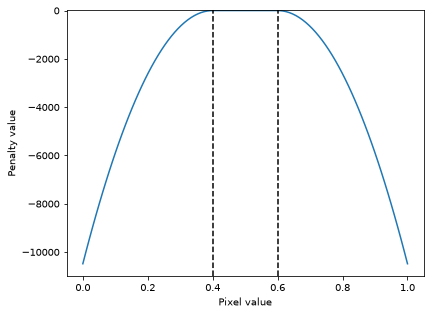

In [8]:
def custom_penalty(image):
    penalty = po.regularize.penalize_range(image, allowed_range=(0.4, 0.6))
    return -penalty


plot_penalty(img, custom_penalty, [0.4, 0.6], (0, 1));

We are trying to minimize the value of `custom_penalty`. Thus, a large negative number is better than 0 (or any positive number). In the plot above, we can see that the penalty is 0 in the allowed range marked by the dashed line and rapidly decreases beyond that range. Thus, the penalty will encourage pixels to lie outside of $[0.4, 0.6]$. Let's see the effect of our penalty on metamer synthesis:

(unbalanced-penalty)=

  0%|          | 0/4000 [00:00<?, ?it/s]

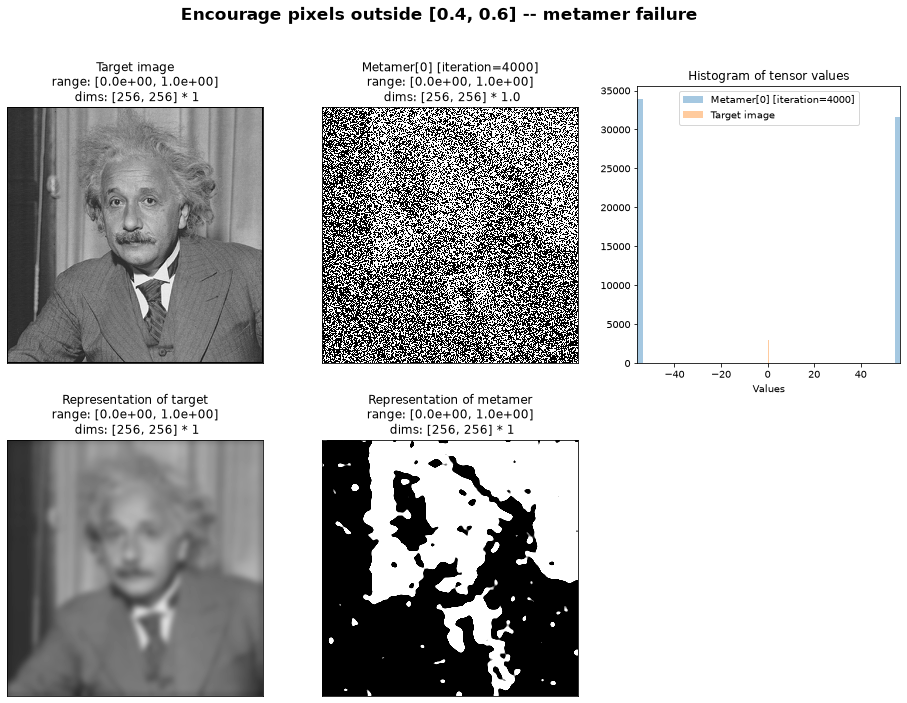

In [9]:
met = po.Metamer(img, model, penalty_function=custom_penalty)
met.synthesize(MAX_ITER, stop_criterion=1e-16)

create_metamer_figure(met, "Encourage pixels outside [0.4, 0.6] -- metamer failure");

Oh no! Our model representations do not look at all identical here.

To see why this is, let's use {func}`plenoptic.plot.synthesis_loss` to plot our metamer loss alongside our penalty value:

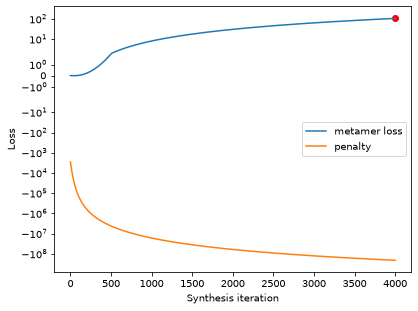

In [10]:
ax = po.plot.synthesis_loss(met, plot_penalties=True)
# convert this to symlog scale, so we can see negative values.
ax["loss"].set_yscale("symlog")

The penalty value is a large negative value and still going lower, whereas the metamer loss has actually increased. Remember that our optimization problem is minimizing the weighted sum of these two numbers; since the metamer loss is bounded below by 0, the penalty has become much more important to the optimization problem, and it can effectively ignore the metamer loss.

Returning to our discussion at the [beginning of the notebook](how-to-penalty), by design, our penalty function is biasing the optimization procedure. Here, however, because the magnitude of the penalty is so much larger than that of the metamer loss, it is biasing the optimization procedure too much, preventing us from finding a solution whose metamer loss is small.

To fix this, we need to change the plot above so that it looks that of the well-behaved penalty. That is, we must remap its range from $(-\infty, 0]$, where 0 corresponds to the values we want to avoid, to $[0, \infty)$ (or $[0, x]$, for some finite $x$), where 0 corresponds to the values we want to encourage. Fortunately, the [exponential function](https://en.wikipedia.org/wiki/Exponential_function) will do this for us, remapping $(-\infty, 0]$ to $[0, 1]$:

In [11]:
def custom_penalty(image):
    penalty = po.regularize.penalize_range(image, allowed_range=(0.4, 0.6))
    return torch.exp(-penalty)

:::{admonition} The remapping function

Using `torch.exp(-penalty)` performs the desired remapping in this case because `penalty` is always non-positive. If the range of the penalty we were remapping included both positive and negative values, we would need some other function.

The goal of this remapping is that the output of your custom penalty should have a finite minimum, which corresponds to the property you wish to encourage.

:::

There's one addition subtlety here: if `penalty` in our function definition above gets too large, `torch.exp` becomes effectively zero and so the penalty has no effect:

In [12]:
penalty = po.regularize.penalize_range(torch.rand_like(img), allowed_range=(0.4, 0.6))
print(penalty.item())
print(torch.exp(-penalty).item())

2813.8978167889936
0.0


To avoid this, let's approximately rescale the input to `torch.exp` so that it never gets too large:

In [13]:
def custom_penalty(image):
    penalty = po.regularize.penalize_range(image, allowed_range=(0.4, 0.6))
    return torch.exp(-penalty / 1000)

With this modification, our custom penalty returns more reasonable values for the types of inputs it is likely to see:

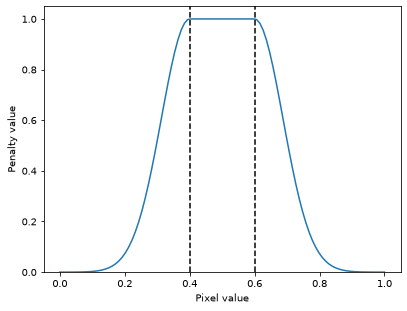

In [14]:
plot_penalty(img, custom_penalty, [0.4, 0.6], (0, 1));

In the above plot we can see that our penalty now varies between 0 and 1, with the maximum occurring within the disallowed values, and decreasing gradually as you move outside the range.

One final modification: when synthesizing images, it is generally desirable for all pixel values to lie within $[0, 1]$, so they can be displayed (which is why this is plenoptic's default behavior, as discussed at the top of this notebook). To ensure that, let's modify our penalty one last time, summing together the two penalties that encourage these two different behaviors.

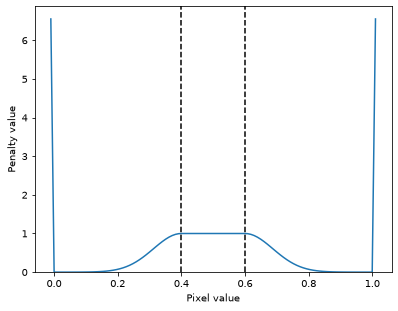

In [15]:
def custom_penalty(image):
    penalty_one = po.regularize.penalize_range(image, allowed_range=(0.4, 0.6))
    penalty_two = po.regularize.penalize_range(image, allowed_range=(0, 1))
    return torch.exp(-penalty_one / 1000) + penalty_two


plot_penalty(img, custom_penalty, [0.4, 0.6], x_range=[-0.01, 1.01]);

In the plot above, we can see that the penalty takes a smaller value when the input satisfies both of our constraints above (that is, all pixel values lie within either $[0, 0.4]$ or $[0.6, 1]$), gradually increases as we move towards $0.4$ or $0.6$ and increases sharply as we move outside $[0, 1]$ (note the range of x-values!).

Now let's use the function for metamer synthesis:

  0%|          | 0/4000 [00:00<?, ?it/s]

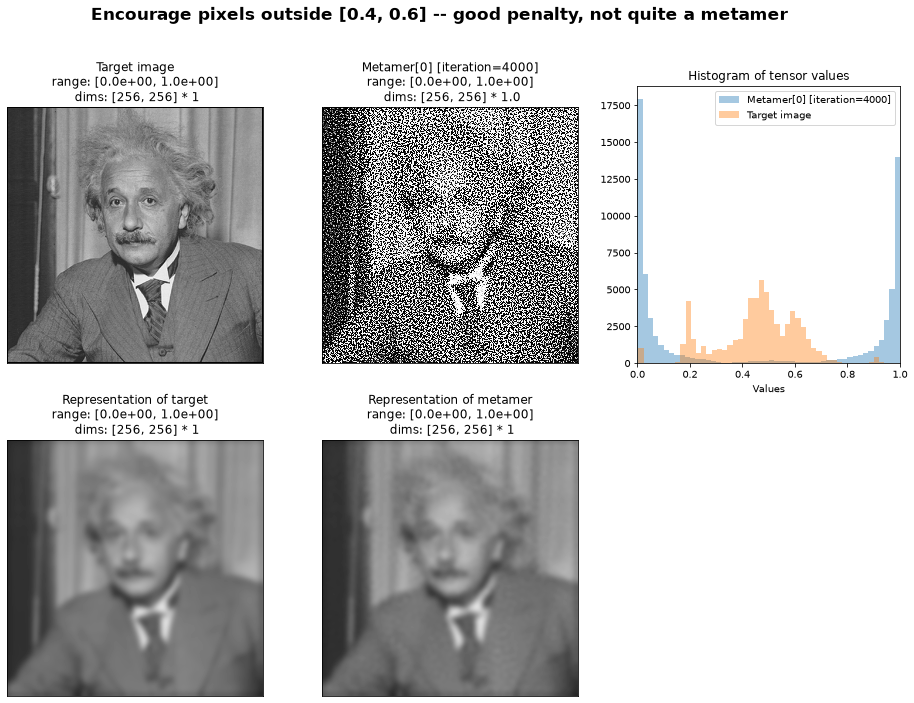

In [16]:
met = po.Metamer(img, model, penalty_function=custom_penalty)
met.synthesize(MAX_ITER, stop_criterion=1e-16)

create_metamer_figure(
    met, "Encourage pixels outside [0.4, 0.6] -- good penalty, not quite a metamer"
);

And now we can see that the model metamer pixel values mostly lie outside the range $[0.4, 0.6]$ and within $[0, 1]$. We can see a couple of other interesting results of our penalty function:
- We have no pixels outside of $[0, 1]$, but we do have some pixels in $[0.4, 0.6]$. If we look at our penalty plot above, we can see that the magnitude of the penalty is much larger for values outside $[0, 1]$ than for those within $[0.4, 0.6]$, so it makes sense that we would see an asymmetry in the resulting metamer. If we do not wish this to be the case, we could multiply the components of the penalty (e.g., `penalty_two`) by some scalar to increase or decrease their relative importance.
- More subtly, it looks like the pixel values are being pushed to a bimodal distribution, clumping near the values 0 and 1, instead of being uniformly distributed within $[0, 0.4]$ and $[0.6, 1]$. Again, returning to the penalty plot above can help explain this: we see that the penalty decreases very gradually as you move away from $0.4$ or $0.6$, and so it only approaches a value and a slope of zero as you near $0.2$ / $0.8$. If we do not wish to see this bimodal distribution, we could instead pick a penalty whose value decreases more rapidly within the allowed range (for example, changing `custom_penalty` above to use `penalty_one = plenoptic.regularize.penalize_range(image, allowed_range=(0.45, 0.65)` or replacing the `torch.exp(-penalty_one / 1000)` with different function entirely, such as a narrow Gaussian centered at 0.5).

We probably could've predicted the above two points by thinking more carefully through the plot of the penalty as a function of the pixel values. This hopefully demonstrates the utility of thinking about your penalty's value and how it will affect your synthesis. When the penalty is operating on pixel values, its behavior is relatively easy to check, but you are encouraged to try any custom penalties on a variety of inputs to better understand their behavior before using them for synthesis!

However, importantly, if you look at the metamer representation image on the second row, you can see that it is not identical to the target representation just next to it (there are faint circles scattered across the image) -- that is, we've failed to find a metamer. We'll address that in the next section.

## Selecting the proper {attr}`~plenoptic.Metamer.penalty_lambda` value
(penalty-lambda)=

In the previous example, we synthesized an image that satisfied the penalty function, but we gave up some of the metamer quality. As discussed at the top of this notebook, that's bad, and results from the penalty playing too large of a role in the objective function. This is the same situation we saw with our [initial attempt](unbalanced-penalty) at the penalty encouraging pixel values to lie outside $[0.4, 0.6]$, though much subtler.

In order to increase the relative importance of the metamer loss (over the penalty) in the objective function, we can use the {attr}`~plenoptic.Metamer.penalty_lambda` argument at initialization. This argument operates similarly to {attr}`~plenoptic.MADCompetition.metric_tradeoff_lambda` from {class}`~plenoptic.MADCompetition`, and allows us to control the balance of these components in the objective function.

This value defaults to 0.1, which you can see by looking at the docstring. Let's try decreasing it:

  0%|          | 0/4000 [00:00<?, ?it/s]

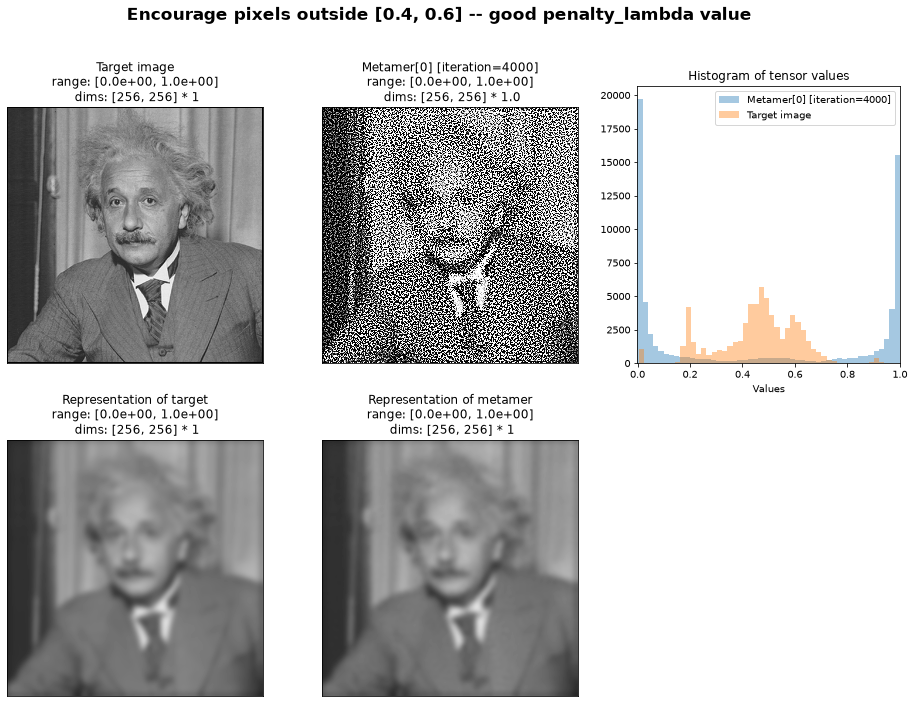

In [17]:
met = po.Metamer(img, model, penalty_function=custom_penalty, penalty_lambda=0.025)
met.synthesize(MAX_ITER, stop_criterion=1e-16)

create_metamer_figure(
    met, "Encourage pixels outside [0.4, 0.6] -- good penalty_lambda value"
);

In the above plots, we can see that the metamer is of good quality (the two bottom images match), and that we have mostly managed to satisfy the constraints from our penalty (most pixel values lie outside the range $[0.4, 0.6]$ and within $[0, 1]$.)

If we continued to decrease {attr}`~plenoptic.Metamer.penalty_lambda`, eventually we'd reach a point where the penalty was having no effect at all:

  0%|          | 0/4000 [00:00<?, ?it/s]

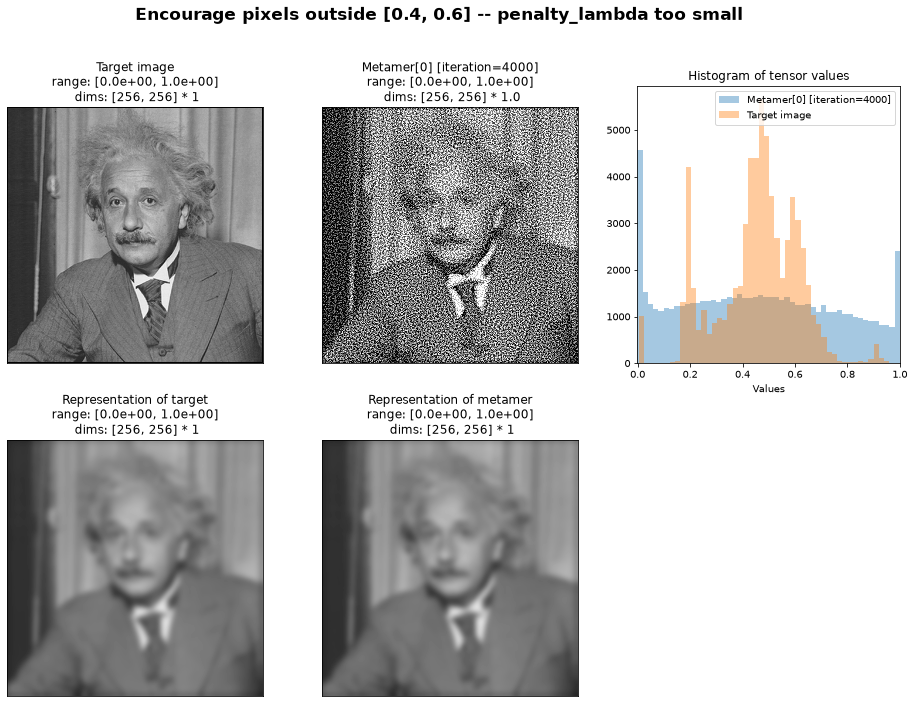

In [18]:
met_small = po.Metamer(img, model, penalty_function=custom_penalty, penalty_lambda=1e-6)
met_small.synthesize(MAX_ITER, stop_criterion=1e-16)

create_metamer_figure(
    met_small, "Encourage pixels outside [0.4, 0.6] -- penalty_lambda too small"
);

While we have a good metamer, we can see that many pixel values in our metamer lie between 0.4 and 0.6 and, indeed, the histogram looks a lot like the [one for the metamer synthesized](default-penalty-figure) using the default penalty.

Conversely, for a very large lambda, the objective function will focus exclusively on minimizing the penalty, ignoring the metamer loss entirely:

  0%|          | 0/4000 [00:00<?, ?it/s]

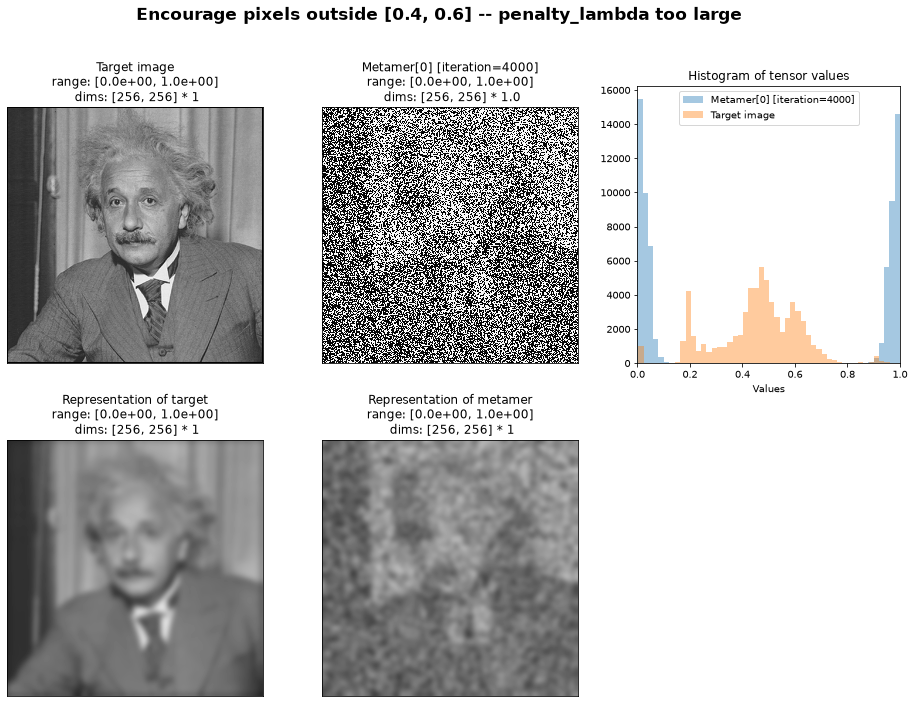

In [19]:
met_large = po.Metamer(img, model, penalty_function=custom_penalty, penalty_lambda=1e6)
met_large.synthesize(MAX_ITER, stop_criterion=1e-16)

create_metamer_figure(
    met_large, "Encourage pixels outside [0.4, 0.6] -- penalty_lambda too large"
);

While we have satisfied our constraint (all pixel values lie within $[0, 0.4]$ or $[0.6, 1]$), we have not successfully found a model metamer.

In all cases, the actual penalty values start at approximately the same value. Because of their relative importance in the objective function, their final value will vary: the larger lambda is, the lower the penalty will become, but at the potential cost of the metamer loss remaining high.

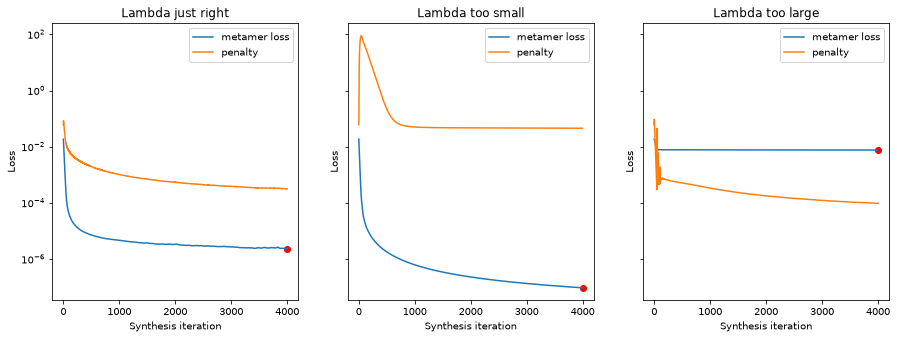

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
po.plot.synthesis_loss(met, plot_penalties=True, ax=axes[0])
axes[0].set_title("Lambda just right")
po.plot.synthesis_loss(met_small, plot_penalties=True, ax=axes[1])
axes[1].set_title("Lambda too small")
po.plot.synthesis_loss(met_large, plot_penalties=True, ax=axes[2])
axes[2].set_title("Lambda too large");

Remember from the [beginning of the notebook](how-to-penalty) that our objective function balances the contribution of these components. Finding the right lambda value so that neither overwhelms the other is key!

## Concluding thoughts

When trying out a new penalty function, you are encouraged to first ensure it complies to best practices, and then try out different values for {attr}`~plenoptic.Metamer.penalty_lambda` to find which one allows you to minimize both the penalty *and* the metamer loss.